### Gas Sensor Array Drift Dataset

#### Core Problem

Industrial sensors drift over time. Their readings drift and become less accurate, even when exposed to the same gas. The challenege is building a classifier that stays accurate despite this drift. This problem is known as concept drift or sensor drift. Machine learning models trained on historical data later degrade in performance.

This project investigates:
1. Whether sensor drift exists across batches
2. How drift affects model performance
3. Which features are most sensitive to drift

**What Was Collected**

- Where: UC San Diego's BioCircuits Institute
- When: January 2007 - February 2011 (36 months)
- How many measurements: 13,910
- How many sensors: 16 chemical sensors running simultaneously
- Gases tested: 6 - Ethanol, Ethylene, Ammonia, Acetaldehyde, Acetone, Toluene
- Concentrations: 5 to 1,000 ppmv (parts per million by volume)

**What Each Data Point Looks Like**

Every single measurement is a 128-dimensional feature vector, built like this. Each of the 16 sensors contributes 8 features, so 16 x 8 = 128 total. Those 8 features per sensor are:

- ΔR: raw resistance change when gas is present
- |ΔR|: normalized version of the above
- 3 EMA features (rising): how fast the sensor reacts when gas hits it (at 3 different smoothing levels: α = 0.001, 0.01, 0.1)
- 3 EMA features (decaying): how fast the sensor recovers after gas is removed (same 3 α values)

The EMAs (Exponential Moving Averages) capture the shape of the sensor's response curve which makes them richer features.

**The Label**

Each row is labeled 1-6 for which gas it is:

| Label | Gas | 
| :-- | :--| 
| 1 | Ethanol |
| 2 | Ethylene |
| 3 | Ammonia |
| 4 | Acetaldehyde |
| 5 | Acetone |
| 6 | Toluene |

**The Drift Challenge**

The data is split into 10 batches covering different months. Batch 1 is early data (months 1-2), Batch 10 is late data (month 36). A naive model trained on Batch 1 will likely perform poorly on Batch 10 because the sensors have drifted. The ML goal is to maintain high accuracy across all batches.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
from pathlib import Path
from sklearn.datasets import load_svmlight_file
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from scipy.stats import ks_2samp, wasserstein_distance

### 1. Data Preparation

In [2]:
def extract_number(path):
    match = re.search(r'\d+', path.name)
    return int(match.group()) if match else 0

dataset_dir = Path("../Dataset")

file_paths = sorted(
    dataset_dir.glob("*.dat"),
    key=extract_number
)

if not file_paths:
    raise ValueError(f"No .dat files found in {dataset_dir}")

dfs = []
feature_names = []

for sensor in range(16):
    feature_names += [
        f"sensor{sensor}_deltaR",
        f"sensor{sensor}_normDeltaR",
        f"sensor{sensor}_EMAi_0.001",
        f"sensor{sensor}_EMAi_0.01",
        f"sensor{sensor}_EMAi_0.1",
        f"sensor{sensor}_EMAd_0.001",
        f"sensor{sensor}_EMAd_0.01",
        f"sensor{sensor}_EMAd_0.1",
    ]

gas_map = {
    1: "ethanol",
    2: "ethylene",
    3: "ammonia",
    4: "acetaldehyde",
    5: "acetone",
    6: "toluene",
}

for i, file in enumerate(file_paths):
    X, y = load_svmlight_file(file)
    
    df = pd.DataFrame(X.toarray())

    if df.shape[1] != 128: raise ValueError()
    df.columns = feature_names
    
    df["target"] = y.astype(int)
    df["target"] = df["target"].map(gas_map)
    
    df["batch_id"] = i + 1
    # string label here to make plotting smoother
    df["batch"] = f"batch_{i+1}"

    dfs.append(df)
        
gas_sensor_df = pd.concat(dfs, ignore_index=True)

cols = ["batch_id", "batch", "target"] + feature_names
gas_sensor_df = gas_sensor_df[cols]

gas_sensor_df.to_parquet('../data/gas_sensor.parquet', engine='pyarrow')

In [3]:
sensor_cols = [col for col in gas_sensor_df.columns if "sensor" in col]

In [4]:
print(gas_sensor_df.info())
print(gas_sensor_df.shape)
print(gas_sensor_df.head())
print(gas_sensor_df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Columns: 131 entries, batch_id to sensor15_EMAd_0.1
dtypes: float64(128), int64(1), str(2)
memory usage: 14.1 MB
None
(13910, 131)
   batch_id    batch   target  sensor0_deltaR  sensor0_normDeltaR  \
0         1  batch_1  ethanol      15596.1621            1.868245   
1         1  batch_1  ethanol      26402.0704            2.532401   
2         1  batch_1  ethanol      42103.5820            3.454189   
3         1  batch_1  ethanol      42825.9883            3.451192   
4         1  batch_1  ethanol      58151.1757            4.194839   

   sensor0_EMAi_0.001  sensor0_EMAi_0.01  sensor0_EMAi_0.1  \
0            2.371604           2.803678          7.512213   
1            5.411209           6.509906          7.658469   
2            8.198175          10.508439         11.611003   
3           12.113940          16.266853         39.910056   
4           11.455096          15.715298         17.654915   

   sensor0_EMAd_

#### Important Features

- deltaR: overall sensitivity drift and baseline shifts
- deltaR normalized: isolates relative behavior changes, removes scale effects
- ema rising: short-term reaction speed, sensitive to environmental and system changes
- ema decay: recovery behavior, decay dynamics degrade over time in sensors

### 2. Drift Analysis

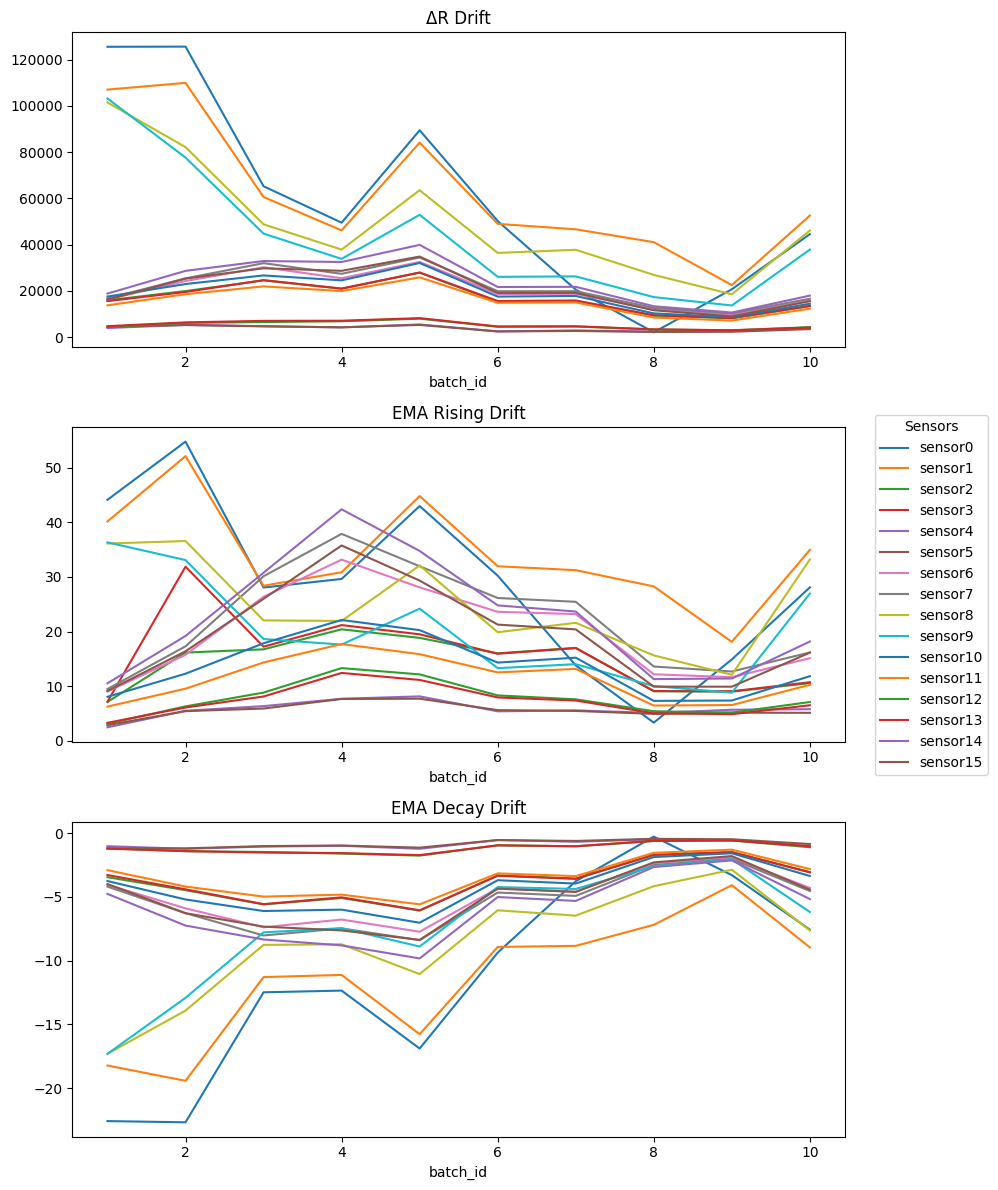

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# ΔR
gas_sensor_df.groupby("batch_id")[sensor_cols[0:128:8]].mean().plot(ax=axes[0], title="ΔR Drift", legend=False)

# EMA rising (fast)
gas_sensor_df.groupby("batch_id")[sensor_cols[4:128:8]].mean().plot(ax=axes[1], title="EMA Rising Drift", legend=False)

# EMA decay (slow)
gas_sensor_df.groupby("batch_id")[sensor_cols[5:128:8]].mean().plot(ax=axes[2], title="EMA Decay Drift", legend=False)

handles, labels = axes[0].get_legend_handles_labels()
cleaned_labels = [l.split('_')[0] for l in labels]
    
fig.legend(handles, cleaned_labels, loc='center right', bbox_to_anchor=(1.00, 0.50), title="Sensors")

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.savefig("../images/drift_plot.png")
plt.show()

Drift is more pronounced in EMA-based features than in steady-state ΔR features, suggesting that sensor response dynamics degrede over time more than magnitude.

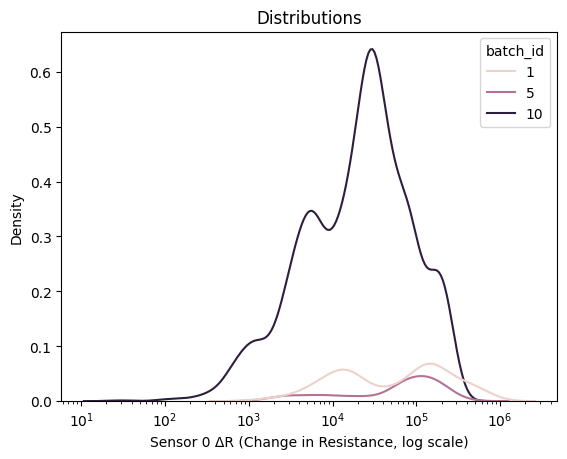

In [6]:
sns.kdeplot(
    data=gas_sensor_df[gas_sensor_df["batch_id"].isin([1, 5, 10])],
    x="sensor0_deltaR",
    hue="batch_id",
    log_scale=True,
)

plt.xlabel("Sensor 0 ΔR (Change in Resistance, log scale)")
plt.title("Distributions")
plt.savefig("../images/sensor0_kde_plot.png")
plt.show()

These plots show that drift is not limited to changes in mean values, but includes full distribution shifts across batches.

In [7]:
early = gas_sensor_df[gas_sensor_df["batch_id"] == 1]["sensor0_deltaR"]
late = gas_sensor_df[gas_sensor_df["batch_id"] == 10]["sensor0_deltaR"]

wasserstein_distance(early, late)

np.float64(81071.38067983584)

The increasing Wasserstein distance between early and late batches quantitatively confirms distribution drift.

#### Isolation Forest

In [8]:
batch1 = gas_sensor_df[gas_sensor_df["batch_id"] == 1][feature_names]
rest = gas_sensor_df[gas_sensor_df["batch_id"] > 1][feature_names]

scaler = StandardScaler()
batch1_scaled = scaler.fit_transform(batch1)
rest_scaled = scaler.transform(rest)

In [9]:
iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
iso.fit(batch1_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [10]:
gas_sensor_df.loc[
    gas_sensor_df["batch_id"] == 1, "anomaly_score"
] = iso.decision_function(batch1_scaled)

gas_sensor_df.loc[
    gas_sensor_df["batch_id"] > 1, "anomaly_score"
] = iso.decision_function(rest_scaled)

In [11]:
gas_sensor_df.groupby("batch_id")["anomaly_score"].mean()

batch_id
1     0.187095
2     0.138637
3     0.092329
4     0.035199
5     0.066868
6     0.124078
7     0.120624
8     0.167342
9     0.163382
10    0.130123
Name: anomaly_score, dtype: float64

#### Pattern Analysis
- Batch 1: 0.187    reference
- Batch 2: 0.139    drift begins
- Batch 3: 0.092    accelerating
- Batch 4: 0.035    worst point
- Batch 5: 0.067    partial recovery
- Batch 6: 0.124    significant recovery
- Batch 7: 0.121    plateau
- Batch 8: 0.167    near-baseline
- Batch 9: 0.163    holds
- Batch 10: 0.130   slight drop

Non-Monotonic Drift

##### Likely Explanations
- **Sensor recalibration** is the most probable cause. Over the dataset's collection period of 36 months, it would be strange to not encounter recalibration. This happening between Batches 5 and 6 would explain the recovery.
- **Batch 4** maps to months 14 and 15, which is a little over a year in. Plausible point for both maximum drift and triggering recalibration.
- **Gas concentration mix** may differ across batches. If later batches used concentration ranges that happen to cluster differently in feature space, the Isolation Forest (trained on Batch 1's distribution) would score them as more normal even without recalibration.

The changes in drift indicate beyond physical degradation. Degradation ramps heavily, to the worst in batch 4 (months 14 and 15). Batch 6 shows significant improvement, likely caused by a recalibration in the sensors. Afterwards declines continue.

#### Drift Detection

In [12]:
batch1_data = gas_sensor_df[gas_sensor_df["batch_id"] == 1]

ks_results = []
for batch_id in range(2,11):
    batch_data = gas_sensor_df[gas_sensor_df["batch_id"] == batch_id]
    for feature in feature_names:
        stat, p = ks_2samp(batch1_data[feature], batch_data[feature])
        ks_results.append({
            "batch_id": batch_id,
            "feature": feature,
            "ks_stat": stat,
            "p_value": p,
            "drifted": p < 0.05
        })

ks_df = pd.DataFrame(ks_results)

In [13]:
print(ks_df[ks_df["drifted"] != True])

      batch_id              feature   ks_stat   p_value  drifted
267          4    sensor1_EMAi_0.01  0.121376  0.055472    False
656          7       sensor2_deltaR  0.058823  0.123375    False
720          7      sensor10_deltaR  0.057378  0.141065    False
1114        10  sensor11_EMAi_0.001  0.051364  0.237893    False


Only 4 out of ~1,280 feature-batch combination didn't drift. This indicates that the entire feature space shifted significantly from Batch 1.

These 4 non-drifted cases are most likely noise rather than signal.
- They're scattered across different batches and sensors with no clear pattern
- Their p-values (0.055, 0.123, 0.141, 0.238) are not confidently non-drifted
- With a high test count of 1,280, false negatives are expected by random chance

#### Cross-Reference With Isolation Forest

KS tests say drift is pervasive and consistent across all batches, but IF scores show recovery in batches 6-9.

Distribution shifted in batches 6-9, and shifted towards something the Isolation Forest considers more normal. Raw feature distributions move, but the overall covariance returns toward baseline.

KS results probably can't be used as a drift detector in isolation. When everything drifts, it won't discriminate well across batches.

In [14]:
ks_df[ks_df["drifted"]].groupby("batch_id")["ks_stat"].mean().sort_values()

batch_id
10    0.224519
2     0.272029
7     0.320483
3     0.339877
6     0.354450
4     0.461243
8     0.468041
9     0.470353
5     0.525035
Name: ks_stat, dtype: float64

In [15]:
ks_df["feature_type"] = ks_df["feature"].str.extract(r'_(EMAi|EMAd|deltaR|normDeltaR)')
print(ks_df.groupby(["batch_id", "feature_type"])["ks_stat"].mean().unstack())

feature_type      EMAd      EMAi    deltaR  normDeltaR
batch_id                                              
2             0.272783  0.304551  0.270659    0.173565
3             0.311182  0.412121  0.330427    0.218681
4             0.442855  0.566885  0.361856    0.277630
5             0.489168  0.649506  0.509187    0.275075
6             0.346309  0.377356  0.277504    0.387097
7             0.311796  0.346488  0.215624    0.340590
8             0.481564  0.413967  0.421076    0.636659
9             0.473545  0.404844  0.471855    0.655803
10            0.203697  0.252396  0.198462    0.218590


#### Two Distinct Stories

##### Story 1

The mean KS ranking contradicts the Isolation Forest ranking:
- IF said worst was Batch 4 (0.035)
- KS said worst was Batch 5 (0.525)

These measure different things. IF is sensitive to multivariate density, how the 128-dimensional point cloud looks together, while KS operates per-feature marginally. Batch 5 may have severe univariate drift that the IF's join structure partially absorbs.

##### Story 2

Early batches (2-5): EMAi leads drift
Late batches (8-9):  normDeltaR dominates (0.636, 0.655, nearly double anything else)


EMAi features capture transient sensor dynamics, how fast the sensor responds. These drifting first suggests the sensor's reaction kinetics are degrading, which is consistent with early-stage physical aging.

normDeltaR drifting severely in batches 8-9 while EMAi calms down is a completely different pattern. normDeltaR is a ratio (max resistence / baseline), so it's acutely sensitive to baseline resistance shifts. This may indicate a structural change in the sensors rather than just surface degradation. Or maybe recalibration corrected the dynamics but introduced a baseline offset.

#### Reconciling IF vs KS

This also explains the puzzle from earlier. Batches 8-9 scored near-baseline on IF (0.167, 0.163) but have high KS drift. The answer is likely that the multivariate covariance structure recovered (which IF picks up on) while normDeltaR's marginal distribution shifted hard (which KS catches but IF partially misses in high dimensions). They're both right, but they're looking at different aspects of the same shift.

1. Drift is universal but non-monotonic — recalibration likely occurred mid-study
2. Early drift is kinetic (EMAi) — sensor response speed degrades first
3. Late drift is structural (normDeltaR) — baseline resistance shifts dominate later

In [16]:
batch_mean_scores = (
    gas_sensor_df.groupby("batch_id")["anomaly_score"]
    .mean()
    .reset_index()
)

# Simple shift detection to flag batches where score drops > 1 std from batch 1
baseline_mean = batch_mean_scores.loc[batch_mean_scores["batch_id"] == 1, "anomaly_score"].values[0]
baseline_std = gas_sensor_df[gas_sensor_df["batch_id"] == 1]["anomaly_score"].std()

batch_mean_scores["drift_flagged"] = batch_mean_scores["anomaly_score"] < (baseline_mean - 2 * baseline_std)

In [17]:
print(batch_mean_scores["drift_flagged"])

0    False
1    False
2    False
3     True
4     True
5    False
6    False
7    False
8    False
9    False
Name: drift_flagged, dtype: bool


In [18]:
def mmd(X, Y, gamma=1.0):
    """RBF kernel MMD estimate between samples X and Y."""
    from sklearn.metrics.pairwise import rbf_kernel
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

batch1_scaled_df = scaler.transform(batch1)
mmd_scores = {}
for batch_id in range(2, 11):
    batch_data = scaler.transform(
        gas_sensor_df[gas_sensor_df["batch_id"] == batch_id][feature_names]
    )
    mmd_scores[batch_id] = mmd(batch1_scaled_df, batch_data)

In [19]:
print(mmd_scores)

{2: np.float64(0.016443756601579294), 3: np.float64(0.012761608465540092), 4: np.float64(0.018451544508141734), 5: np.float64(0.017005403874079134), 6: np.float64(0.02631022467751076), 7: np.float64(0.008301740893053928), 8: np.float64(0.0528119419611385), 9: np.float64(0.05398685047662217), 10: np.float64(0.007644188018265979)}


#### Maximum Mean Discrepancy Results

- Batch 7:  0.0083  near zero
- Batch 8:  0.0528  6x jump
- Batch 9:  0.0540  sustained
- Batch 10: 0.0076  suddenly drops back

- IF scores flagged:  Batches 3 and 4
- KS statistic worst: Batch 5
- MMD worst:          Batches 8 and 9

The cliff between batch 7 and 8, and the sudden return at batch 10, is a structural break rather than gradual drift. MMD with an RBF kernel is capturing joint distributional distance in the full scaled 128-dimensional space. It's saying batches 8 and 9 are fundamentally different from Batch 1 in a way the other metrics did not fully catch.

This ties directly to the KS finding that normDeltaR exploded in batches 8-9 (0.636, 0.655). MMD is especially sensitive to feature-scale shifts because the RBF kernel responds strongly to distance in any direction.

##### Why IF Missed It

The IF drift flag only caught batches 3 and 4, and scored batches 8-9 as near-normal. This can actually be explained clearly now. Isolation Forest isolates points by how easy they are to separate from the bulk. If the whole batch shifted together coherently (as a recalibration would cause(), the points remain dense relative to each other and IF scores them as normal. MMD doesn't care about internal density, only distance from the reference distribution.

#### The Revised Picture

| Batch | IF Score | KS Mean | Drift Flagged | MMD | Interpretation |
| :-- | :-- | :-- | :-- | :-- | :-- |
| 1 | 0.187 | - | False | - | Reference |
| 2 | 0.139 | 0.272 | False | 0.016 | Early degradation |
| 3 | 0.092 | 0.340 | True | 0.013 | Accelerating |
| 4 | 0.035 | 0.461 | True | 0.018 | IF worst point |
| 5 | 0.067 | 0.525 | False | 0.017| KS worst point |
| 6 | 0.124 | 0.354 | False | 0.026 | Partial recovery |
| 7 | 0.121 | 0.320 | False | 0.008 | Most similar to B1 |
| 8 | 0.167 | 0.468 | False | 0.053 | MMD worst |
| 9 | 0.163 | 0.470 | False | 0.054 | MMD worst |
| 10 | 0.130 | 0.225 | False | 0.008 | Sudden return |

#### The Revised Narrative

There are arguably two separate drift events in this dataset:

- Event 1 (Batches 2-5): Sensor kinetics degrade (EMAi-led), IF and KS detect, scores recover around batch 6. This is consistent with recalibration correcting the dynamic response.
- Event 2 (Batches 8-9): A structural baseline shift (normDeltaR-led) that recalibration didn't fully correct or introduced itself. IF misses it because the shift is coherent across all samples. Only MMD catches its true severity. Batch 10 snapping back to near-zero MMD is then consistent with another recalibration or end-of-study correction.

#### Implications for a Classifier

The most difficult generalization problem is training on anything before Batch 8 and testing on Batch 8 or 9, because the baseline resistance shift represents a qualitatively different kind of drift that no amount of kinetic compensation handles. May need to test a train/test split on that data explicitly

### 3. Evaluating Model Performance Under Drift

To quantify the impact of sensor drift, we define two evaluation scenarios:

- **Floor (No Adaptation):**  
  A model is trained on Batch 1 and applied to all subsequent batches.  
  This simulates a real-world deployment where the model is not updated over time.

- **Oracle (Full Adaptation):**  
  A model is trained and evaluated within each batch using cross-validation.  
  This represents an upper bound where the model has full access to the current data distribution.

The gap between these two scenarios reflects the performance degradation caused by distribution drift.

#### Classifier Baselines

In [20]:
# floor: train only on batch 1, test on all
# ceiling: train and test on each batch separately

results = []

# fit floor model
X_train = gas_sensor_df[gas_sensor_df["batch_id"] == 1][feature_names]
y_train = gas_sensor_df[gas_sensor_df["batch_id"] == 1]["target"]

scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)

# Batch 1 params from the dataset author's recommendation: C=256, gamma=0.03125
floor_model = SVC(C=256, gamma=0.03125, kernel="rbf", random_state=42)
floor_model.fit(X_train_scaled, y_train)

for batch_id in range(1,11):
    batch = gas_sensor_df[gas_sensor_df["batch_id"] == batch_id]
    X_test = scaler_clf.transform(batch[feature_names])
    y_test = batch["target"]

    floor_score = accuracy_score(y_test, floor_model.predict(X_test))

    oracle_scaler = StandardScaler()
    X_oracle = oracle_scaler.fit_transform(batch[feature_names])
    oracle_model = SVC(C=256, gamma=0.03125, kernel="rbf", random_state=42)
    oracle_model.fit(X_oracle, y_test)
    oracle_score = cross_val_score(oracle_model, X_oracle, y_test, cv=5).mean()

    results.append({
        "batch_id": batch_id,
        "floor_accuracy": floor_score,
        "oracle_accuracy": oracle_score,
    })

baseline_df = pd.DataFrame(results)

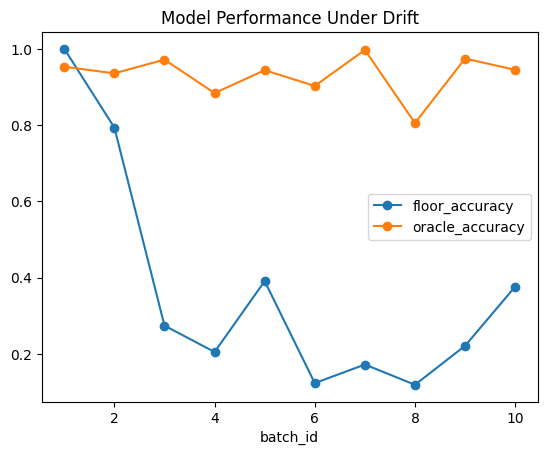

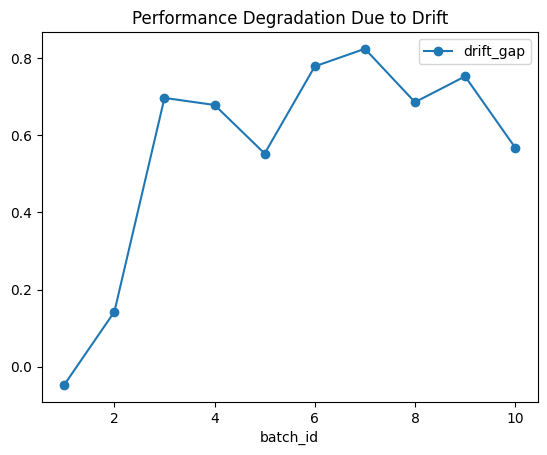

In [21]:
baseline_df["drift_gap"] = baseline_df["oracle_accuracy"] - baseline_df["floor_accuracy"]

baseline_df.plot(
    x="batch_id",
    y=["floor_accuracy", "oracle_accuracy"],
    marker="o",
    title="Model Performance Under Drift"
)
plt.savefig("../images/model_performance_drift_plot.png")

baseline_df.plot(
    x="batch_id",
    y="drift_gap",
    marker="o",
    title="Performance Degradation Due to Drift"
)
plt.savefig("../images/performance_degradation_plot.png")

Model performance under the floor scenario degrades as batch_id increases, indicating that the model trained on early data fails to generalize to later distributions.

In contrast, the oracle model maintains consistently high performance, demonstrating that the degradation is not due to model capacity but rather distribution shift.

The widening gap between floor and oracle performance quantifies the impact of sensor drift and highlights the need for periodic retraining or adaptation.

#### Drift-Aware Feature Weighting

KS analysis showed which features drift most. It will be used to down-weight unstable features during training.

In [22]:
feature_stability = (
    ks_df.groupby("feature")["ks_stat"]
    .mean()
)

stability_weights = 1 - (feature_stability - feature_stability.min()) / (feature_stability.max() - feature_stability.min())
stability_weights = stability_weights[feature_names].values

def apply_feature_weights(X_scaled, weights):
    return X_scaled * weights

X_train_weighted = apply_feature_weights(X_train_scaled, stability_weights)

#### Importance Weighting for Covariate Shift

IF anomaly scores gave a per-sample measure of how far each point is from Batch 1's distribution. We'll use this here to reweight training samples. Points that look more like the test distribution will get higher weight.

In [23]:
def estimate_importance_weights(X_source, X_target):
    """
    Train a classifier to distinguish source from target.
    Samples that look more like the target get higher weight.
    """
    X_combined = np.vstack([X_source, X_target])
    y_combined = np.array([0] * len(X_source) + [1] * len(X_target))

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_combined, y_combined)

    # P(target[x]/P(source|X) for source samples
    probs = clf.predict_proba(X_source)
    weights = probs[:,1] / (probs[:,0] + 1e-10)
    weights = np.clip(weights, 0.1, 10)
    return weights/weights.mean()

weighted_results = []
for batch_id in range(2,11):
    target_batch = gas_sensor_df[gas_sensor_df["batch_id"] == batch_id]
    X_target = scaler_clf.transform(target_batch[feature_names])
    y_target = target_batch["target"]
    
    weights = estimate_importance_weights(X_train_scaled, X_target)
    
    weighted_model = SVC(C=256, gamma=0.03125, kernel="rbf", random_state=42)
    weighted_model.fit(X_train_scaled, y_train, sample_weight=weights)
    
    score = accuracy_score(y_target, weighted_model.predict(X_target))
    weighted_results.append({"batch_id": batch_id, "weighted_accuracy": score})

#### Separately Handle Drift Regimes

In [24]:
# Regime 1: Batches 2-5 (kinetic drift, EMAi-led)
# down-weight EMAi features

ema_i_features = [f for f in feature_names if "EMAi" in f]
regime1_weights = np.ones(len(feature_names))
regime1_weights[[feature_names.index(f) for f in ema_i_features]] = 0.3

# Regime 2: Batches 8-9 (structural drift, normDeltaR-led)
# down-weight normDeltaR features

norm_dr_features = [f for f in feature_names if "normDeltaR" in f]
regime2_weights = np.ones(len(feature_names))
regime2_weights[[feature_names.index(f) for f in norm_dr_features]] = 0.3

def get_regime_weights(batch_id):
    if batch_id <= 5:
        return regime1_weights
    elif batch_id in [8,9]:
        return regime2_weights
    else:
        return np.ones(len(feature_names))

In [25]:
final_results = []

for batch_id in range(1, 11):
    batch = gas_sensor_df[gas_sensor_df["batch_id"] == batch_id]
    X_test_raw = scaler_clf.transform(batch[feature_names])
    y_test = batch["target"]
    
    regime_weights = get_regime_weights(batch_id)
    
    # Apply both feature weighting and regime weights
    combined_weights = stability_weights * regime_weights
    combined_weights /= combined_weights.mean()
    
    X_train_final = apply_feature_weights(X_train_scaled, combined_weights)
    X_test_final = apply_feature_weights(X_test_raw, combined_weights)
    
    # Importance weights for covariate shift
    imp_weights = estimate_importance_weights(X_train_scaled, X_test_raw) \
                  if batch_id > 1 else np.ones(len(X_train_scaled))
    
    model = SVC(C=256, gamma=0.03125, kernel="rbf", random_state=42)
    model.fit(X_train_final, y_train, sample_weight=imp_weights)
    
    score = accuracy_score(y_test, model.predict(X_test_final))
    final_results.append({"batch_id": batch_id, "final_accuracy": score})

final_df = pd.DataFrame(final_results)
comparison_df = baseline_df.merge(final_df, on="batch_id")
print(comparison_df)

   batch_id  floor_accuracy  oracle_accuracy  drift_gap  final_accuracy
0         1        1.000000         0.952809  -0.047191        1.000000
1         2        0.793408         0.935594   0.142186        0.810289
2         3        0.274275         0.971617   0.697342        0.393443
3         4        0.204969         0.883902   0.678933        0.254658
4         5        0.390863         0.943846   0.552983        0.487310
5         6        0.123478         0.902609   0.779130        0.223913
6         7        0.172156         0.996956   0.824799        0.215057
7         8        0.119048         0.805260   0.686212        0.187075
8         9        0.221277         0.974468   0.753191        0.463830
9        10        0.376389         0.944722   0.568333        0.489722


### 4. Drift Impact on Model Performance

#### oof

Consistently beats the floor, but has a huge gap between it and the oracle.

- Batch 2:   floor 0.793 - final 0.810  (modest gain, already decent)
- Batch 5:   floor 0.391 - final 0.487  (+10 points)
- Batch 6:  floor 0.123 - final 0.224   (still basically failing)
- Batch 7:  floor 0.172 - final 0.215   (almost no improvement)
- Batch 9:   floor 0.221 - final 0.464  (+24 points, best improvement)
- Batch 10:  floor 0.376 - final 0.490  (+11 points)

Batch 7 had the lowest MMD of any batch (0.0083, nearly identical to Batch 1 in joint distribution) yet accuracy is 21.5%. That's a contradiction worth investigating. If the distributions are similar, a Batch 1 trained model should perform well. Something else is happening, and the most likely explanation is class distribution shift: the same feature space but different proportions of gases tested in that batch, which none of our drift metrics capture.

#### Continual learning

Rather than just training on Batch 1, we'll now accumulate batches sequentially.

In [26]:
cumulative_results = []

for test_batch_id in range(2, 11):
    # Train on all batches that are before the test batch
    train_data = gas_sensor_df[gas_sensor_df["batch_id"] < test_batch_id]
    test_data = gas_sensor_df[gas_sensor_df["batch_id"] == test_batch_id]
    
    X_train = train_data[feature_names]
    y_train = train_data["target"]
    X_test = test_data[feature_names]
    y_test = test_data["target"]
    
    scaler_cum = StandardScaler()
    X_train_scaled = scaler_cum.fit_transform(X_train)
    X_test_scaled = scaler_cum.transform(X_test)
    
    model = SVC(C=256, gamma=0.03125, kernel="rbf", random_state=42)
    model.fit(X_train_scaled, y_train)
    
    score = accuracy_score(y_test, model.predict(X_test_scaled))
    cumulative_results.append({
        "batch_id": test_batch_id,
        "cumulative_accuracy": score
    })

In [27]:
for res in cumulative_results:
    print(res)

{'batch_id': 2, 'cumulative_accuracy': 0.7934083601286174}
{'batch_id': 3, 'cumulative_accuracy': 0.8984867591424969}
{'batch_id': 4, 'cumulative_accuracy': 0.7142857142857143}
{'batch_id': 5, 'cumulative_accuracy': 0.9137055837563451}
{'batch_id': 6, 'cumulative_accuracy': 0.6930434782608695}
{'batch_id': 7, 'cumulative_accuracy': 0.8438970384721838}
{'batch_id': 8, 'cumulative_accuracy': 0.8231292517006803}
{'batch_id': 9, 'cumulative_accuracy': 0.8829787234042553}
{'batch_id': 10, 'cumulative_accuracy': 0.66}


### 5. Key Insights

#### Revised Narrative

- Batch 1-only training:  proves the drift problem is real and severe
- Feature/importance weighting: modest gains, validates the analytical approach
- Cumulative training: shows dramatic improvement
- Batch 7 anomaly:  demonstrates that drift isn't the only failure mode